# 01 — Data Audit and EDA

In [ ]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "online_retail_II.xlsx"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
MODELS = PROJECT_ROOT / "models"

DATA_PROCESSED.mkdir(exist_ok=True, parents=True)
FIGURES.mkdir(exist_ok=True, parents=True)
MODELS.mkdir(exist_ok=True, parents=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

assert DATA_RAW.exists(), f"Raw dataset not found: {DATA_RAW}"

xl = pd.ExcelFile(DATA_RAW)
print("Sheets:", xl.sheet_names)

frames = []
for sheet in xl.sheet_names:
    temp = pd.read_excel(DATA_RAW, sheet_name=sheet)
    temp["SourceSheet"] = sheet
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

print("Combined shape:", df.shape)
display(df.head())
display(df.tail())

Sheets: ['Year 2009-2010', 'Year 2010-2011']
Combined shape: (1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Year 2010-2011
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Year 2010-2011
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Year 2010-2011
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,Year 2010-2011
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France,Year 2010-2011


## 1. Data structure and data types

In [2]:
print(df.info())
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
 8   SourceSheet  1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 73.3+ MB
None


,dtype,missing_count,missing_pct,n_unique
Customer ID,float64,243007,22.77,5942
Description,object,4382,0.41,5698
Invoice,object,0,0.00,53628
Quantity,int64,0,0.00,1057
StockCode,object,0,0.00,5305
InvoiceDate,datetime64[us],0,0.00,47635
Price,float64,0,0.00,2807
Country,str,0,0.00,43
SourceSheet,str,0,0.00,2


## 2. Basic quality audit

In [3]:
duplicate_count = int(df.duplicated().sum())
negative_qty = int((df["Quantity"] < 0).sum())
zero_price = int((df["Price"] == 0).sum())
negative_price = int((df["Price"] < 0).sum())
missing_customer = int(df["Customer ID"].isna().sum())
missing_description = int(df["Description"].isna().sum())
cancellations = int(df["Invoice"].astype(str).str.startswith("C").sum())

audit = pd.DataFrame({
    "Issue": [
        "Exact duplicate rows",
        "Negative quantities",
        "Zero prices",
        "Negative prices",
        "Missing Customer ID",
        "Missing Description",
        "Cancellation invoices"
    ],
    "Count": [
        duplicate_count, negative_qty, zero_price, negative_price,
        missing_customer, missing_description, cancellations
    ]
})
audit["Percent of rows"] = (audit["Count"] / len(df) * 100).round(2)
display(audit)

,Issue,Count,Percent of rows
0,Exact duplicate rows,12133,1.14
1,Negative quantities,22950,2.15
2,Zero prices,6202,0.58
3,Negative prices,5,0.00
4,Missing Customer ID,243007,22.77
5,Missing Description,4382,0.41
6,Cancellation invoices,19494,1.83


## 3. Date range and coverage

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())
print("Unique customers:", df["Customer ID"].nunique())
print("Countries:", df["Country"].nunique())

Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00
Unique customers: 5942
Countries: 43


## 4. Descriptive statistics

In [5]:
numeric_cols = ["Quantity", "Price"]
desc = df[numeric_cols].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
desc["skewness"] = df[numeric_cols].skew()
display(desc)

,count,mean,std,min,1%,25%,50%,75%,99%,max,skewness
Quantity,1067371.0,9.938898,172.705794,-80995.00,-3.00,1.00,3.0,10.00,100.0,80995.0,3.996145
Price,1067371.0,4.649388,123.553059,-53594.36,0.21,1.25,2.1,4.15,18.0,38970.0,-69.164734


## 5. Transaction-value diagnostic

In [6]:
eda = df.copy()
eda["TotalPrice"] = eda["Quantity"] * eda["Price"]

print("TotalPrice summary:")
display(eda["TotalPrice"].describe(percentiles=[0.01, 0.5, 0.75, 0.95, 0.99]).to_frame())

TotalPrice summary:


,TotalPrice
count,1.067371e+06
mean,1.806987e+01
std,2.924202e+02
min,-1.684696e+05
1%,-7.950000e+00
50%,9.900000e+00
75%,1.770000e+01
95%,5.950000e+01
99%,1.800000e+02
max,1.684696e+05


## 6. Relationships and visualizations

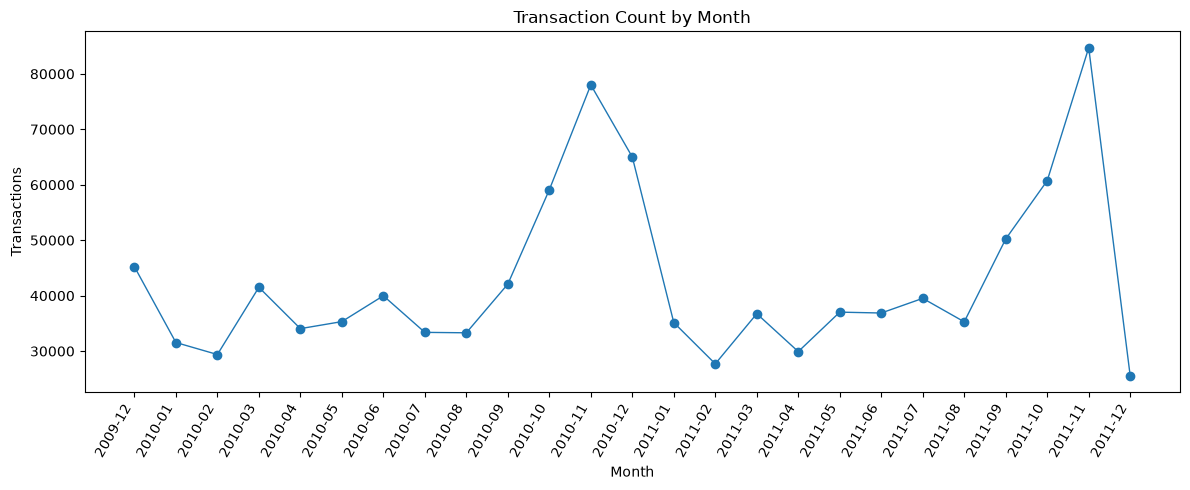

In [ ]:
monthly = (
    df.assign(Month=df["InvoiceDate"].dt.to_period("M").astype(str))
      .groupby("Month").size()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, marker="o", linewidth=1)
plt.xticks(rotation=60, ha="right")
plt.title("Transaction Count by Month")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.tight_layout()
plt.savefig(FIGURES / "monthly_transaction_count.png", dpi=160)
plt.show()

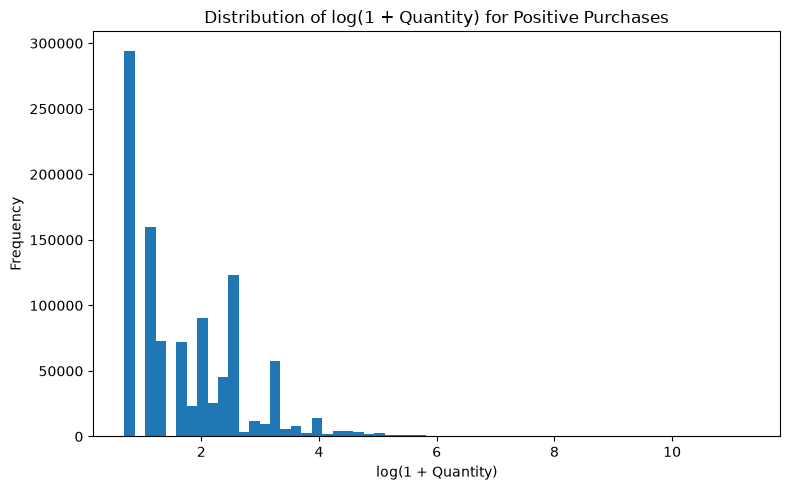

In [ ]:
q = df.loc[df["Quantity"] > 0, "Quantity"]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(q), bins=60)
plt.title("Distribution of log(1 + Quantity) for Positive Purchases")
plt.xlabel("log(1 + Quantity)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES / "quantity_log_distribution.png", dpi=160)
plt.show()

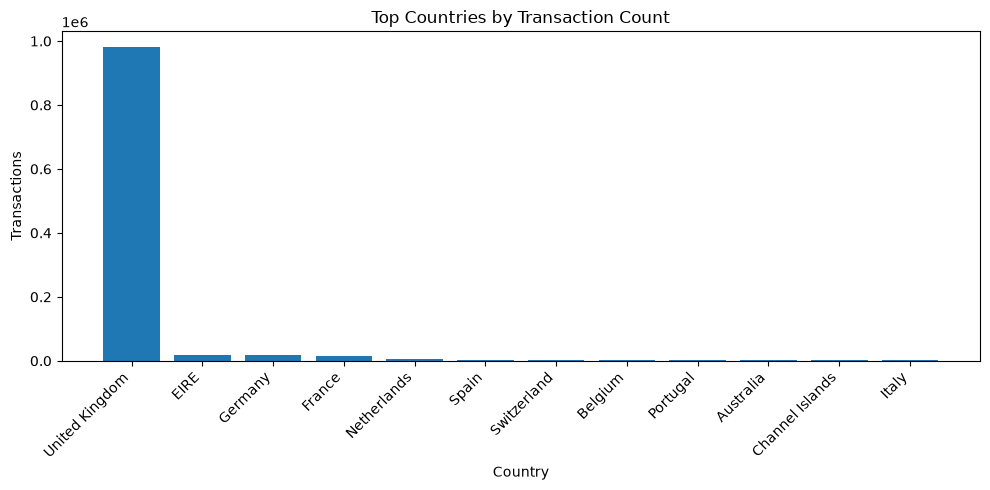

In [ ]:
country_counts = df["Country"].value_counts().head(12)

plt.figure(figsize=(10, 5))
plt.bar(country_counts.index.astype(str), country_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top Countries by Transaction Count")
plt.xlabel("Country")
plt.ylabel("Transactions")
plt.tight_layout()
plt.savefig(FIGURES / "top_countries_transactions.png", dpi=160)
plt.show()